# 04 - Logistic Regression PD Model

## Credit Risk Modelling Using Logistic Regression

This notebook estimates the Probability of Default for serious delinquency within two years with logistic regression. It uses a stratified train/test split, learns scaling values from training data, and reports training-sample coefficient inference. The holdout is reserved for Notebook 05.

## Model definition

For borrower $i$, let $Y_i=1$ indicate serious delinquency within two years. The model assumes

$$
Y_i \sim \operatorname{Bernoulli}(p_i),
\qquad
\log\left(\frac{p_i}{1-p_i}\right)
=
\beta_0+\sum_{j=1}^{k}\beta_j X_{ij}.
$$

Thus, the fitted probability $\hat p_i$ is the borrower's estimated **Probability of Default (PD)**. Coefficients are estimated by maximum likelihood using statsmodels. Predictors are standardized using training-sample means and standard deviations; odds ratios therefore describe a one-standard-deviation increase in a predictor, holding the other model predictors fixed. These are conditional associations, not causal effects.

## 1. Prepare predictors and reserve a holdout

The target and two engineered features from Notebook 03 are prepared through the reusable modules. The composite delinquency count is used in place of the three highly overlapping delinquency counts. Scaling parameters are learned after the split from the training partition only. The fixed random seed makes the split reproducible.

In [1]:
import sys
import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.insert(0, "../src")
from model import prepare_data, split_data, scale_data, fit_logit, coefficient_table

DATA_PATH = "../data/processed/cleaned_data.csv"
MODEL_PATH = "../models/logistic_regression.pkl"
FIG_PATH = "../reports/figures/04_odds_ratios.png"
SEED = 47

clean_data = pd.read_csv(DATA_PATH)
feat, target = prepare_data(clean_data)
train_feat, test_feat, train_y, test_y = split_data(feat, target, SEED)
scaler, train_scaled, test_scaled = scale_data(train_feat, test_feat)

split_tab = pd.DataFrame({
    "partition": ["Training", "Holdout"],
    "borrowers": [len(train_y), len(test_y)],
    "defaults": [int(train_y.sum()), int(test_y.sum())],
    "default_rate_percent": [train_y.mean() * 100, test_y.mean() * 100],
})
display(split_tab.round({"default_rate_percent": 3}))
print(f"Predictors: {len(feat.columns)}")
print("Holdout is reserved for Notebook 05 and is not used to estimate coefficients.")

,partition,borrowers,defaults,default_rate_percent
0,Training,101893,6882,6.754
1,Holdout,43669,2949,6.753


Predictors: 8
Holdout is reserved for Notebook 05 and is not used to estimate coefficients.


## 2. Fit the logistic regression on training data

An intercept is included in the design matrix. The model uses the eight specified predictors and no holdout observations. Statistical tests and intervals below rely on the usual maximum-likelihood large-sample approximation.

In [2]:
fit_result = fit_logit(train_scaled, train_y)
coef_tab = coefficient_table(fit_result)
display(coef_tab.round({
    "coefficient": 4,
    "std_error": 4,
    "z_value": 3,
    "p_value": 6,
    "ci_lower": 4,
    "ci_upper": 4,
    "odds_ratio_per_sd": 4,
    "or_ci_lower": 4,
    "or_ci_upper": 4,
}))
print(f"Converged: {fit_result.mle_retvals['converged']}")
print(f"Training log-likelihood: {fit_result.llf:,.2f}")
print(f"Training observations: {int(fit_result.nobs):,}")

,coefficient,std_error,z_value,p_value,ci_lower,ci_upper,odds_ratio_per_sd,or_ci_lower,or_ci_upper
const,-2.7407,0.0138,-197.911,0.000000,-2.7678,-2.7136,0.0645,0.0628,0.0663
age,-0.4545,0.0145,-31.401,0.000000,-0.4829,-0.4262,0.6348,0.6170,0.6530
RevolvingUtilizationOfUnsecuredLines,-0.0174,0.0185,-0.939,0.347866,-0.0538,0.0189,0.9827,0.9477,1.0191
DebtRatio,-0.0212,0.0250,-0.849,0.396149,-0.0703,0.0278,0.9790,0.9322,1.0282
LogMonthlyIncome,-0.0170,0.0122,-1.395,0.163064,-0.0409,0.0069,0.9831,0.9599,1.0069
TotalDelinquencies,0.1646,0.0103,15.956,0.000000,0.1444,0.1848,1.1789,1.1553,1.2030
NumberOfOpenCreditLinesAndLoans,-0.0355,0.0151,-2.344,0.019068,-0.0652,-0.0058,0.9651,0.9369,0.9942
NumberRealEstateLoansOrLines,0.0310,0.0144,2.159,0.030818,0.0029,0.0591,1.0315,1.0029,1.0609
NumberOfDependents,0.1155,0.0117,9.906,0.000000,0.0926,0.1383,1.1224,1.0971,1.1484


Converged: True
Training log-likelihood: -24,194.95
Training observations: 101,893


## 3. Interpret coefficients and odds ratios

For a standardized predictor $X_j$, $\exp(\hat{\beta}_j)$ is the estimated multiplicative change in the odds of serious delinquency associated with a one-standard-deviation increase, conditional on the other included predictors. Values above 1 indicate higher fitted odds; values below 1 indicate lower fitted odds. A 95% confidence interval for the odds ratio is obtained by exponentiating the coefficient interval.

Small p-values indicate evidence against a zero coefficient under the model and sampling assumptions. They do not establish causation or practical importance. Correlated predictors, extreme records, omitted variables, and functional-form misspecification can affect these estimates.

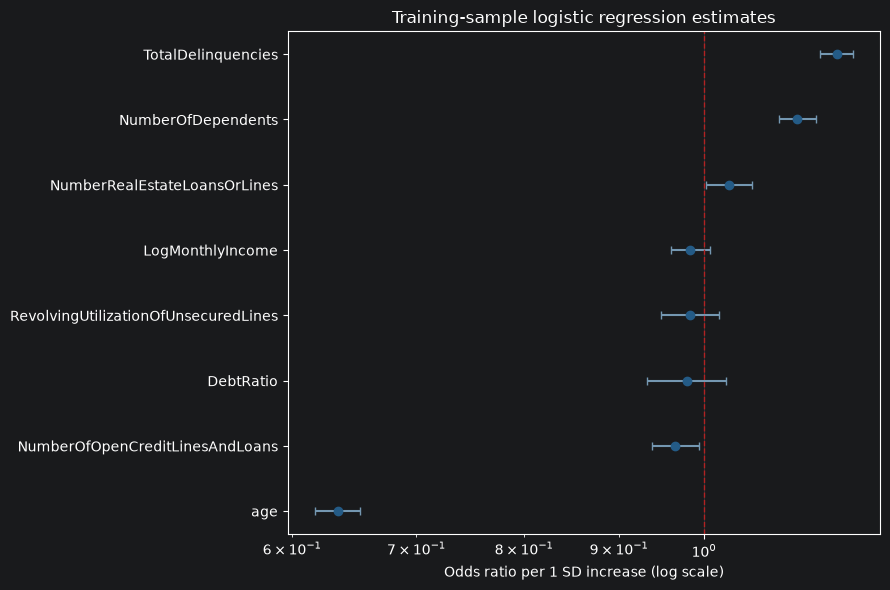

Saved coefficient figure to ../reports/figures/04_odds_ratios.png


In [3]:
or_tab = coef_tab.drop(index="const").sort_values("odds_ratio_per_sd")
pos = range(len(or_tab))
fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(
    or_tab["odds_ratio_per_sd"],
    pos,
    xerr=[
        or_tab["odds_ratio_per_sd"] - or_tab["or_ci_lower"],
        or_tab["or_ci_upper"] - or_tab["odds_ratio_per_sd"],
    ],
    fmt="o",
    color="#245b86",
    ecolor="#7497b1",
    capsize=3,
)
ax.axvline(1, color="#b22222", linestyle="--", linewidth=1)
ax.set_yticks(list(pos))
ax.set_yticklabels(or_tab.index)
ax.set_xscale("log")
ax.set_xlabel("Odds ratio per 1 SD increase (log scale)")
ax.set_title("Training-sample logistic regression estimates")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
os.makedirs("../reports/figures", exist_ok=True)
fig.savefig(FIG_PATH, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved coefficient figure to {FIG_PATH}")

## 4. Save the fitted model for Notebook 05

Save the training-fitted coefficients, predictor names, training-only scaling values, and split seed together. Notebook 05 can reproduce the same stratified holdout, transform it with the training scaler, and assess discrimination, calibration, and risk deciles without refitting on holdout outcomes.

In [4]:
os.makedirs("../models", exist_ok=True)
model_pack = {
    "coef": fit_result.params.to_dict(),
    "scale_mean": scaler.mean_.tolist(),
    "scale_std": scaler.scale_.tolist(),
    "features": list(feat.columns),
    "seed": SEED,
}
with open(MODEL_PATH, "wb") as model_file:
    pickle.dump(model_pack, model_file)
print(f"Saved training-fitted model package to {MODEL_PATH}")

Saved training-fitted model package to ../models/logistic_regression.pkl


## Findings and interpretation

- The stratified split contains **101,893 training borrowers** (6.754% defaults) and **43,669 holdout borrowers** (6.753%). The maximum-likelihood fit converged on the training sample.
- Holding the other included predictors fixed, a one-standard-deviation increase in age is associated with lower fitted odds of serious delinquency (**OR 0.635**, 95% CI 0.617–0.653). Total delinquencies (**OR 1.179**, 95% CI 1.155–1.203) and number of dependents (**OR 1.122**, 95% CI 1.097–1.148) are associated with higher fitted odds.
- Open credit lines (**OR 0.965**, 95% CI 0.937–0.994; p=0.019) and real-estate loans (**OR 1.032**, 95% CI 1.003–1.061; p=0.031) have small nominal associations at the 5% level. These p-values are unadjusted for examining multiple coefficients, so treat the findings cautiously.
- The linear terms for revolving utilization, debt ratio, and log income are not statistically distinguishable from zero at the 5% level; their 95% odds-ratio intervals include 1. This does not negate the group patterns from Notebook 03. A single linear term may not capture the nonlinear utilization pattern, and extreme tails may influence estimates.
- Predictors are standardized, so each odds ratio refers to one training-sample standard deviation, not one original unit. Statistical significance does not establish causation or out-of-sample usefulness.
- Notebook 05 evaluates the reserved holdout, calibration, discrimination, and risk segmentation. Further model diagnostics could examine logit functional form, multicollinearity, and influential observations. No holdout performance metric is reported here.

The saved model package contains fitted coefficients and training-only scaling values for reproducible holdout scoring.